In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
data = pd.read_csv("../data/raw/project_risk_raw_dataset.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

In [10]:
if data.isna().any().any():
    print("Null values in the dataset:")
    for col in data.columns:
        if data[col].isna().any():
            print(f"- {col} has {data[col].isna().sum()*100/len(data):.2f}% null values")
else:
    print("No null values found.")

Null values in the dataset:
- Tech_Environment_Stability has 65.47% null values
- Change_Control_Maturity has 19.50% null values
- Risk_Management_Maturity has 19.77% null values


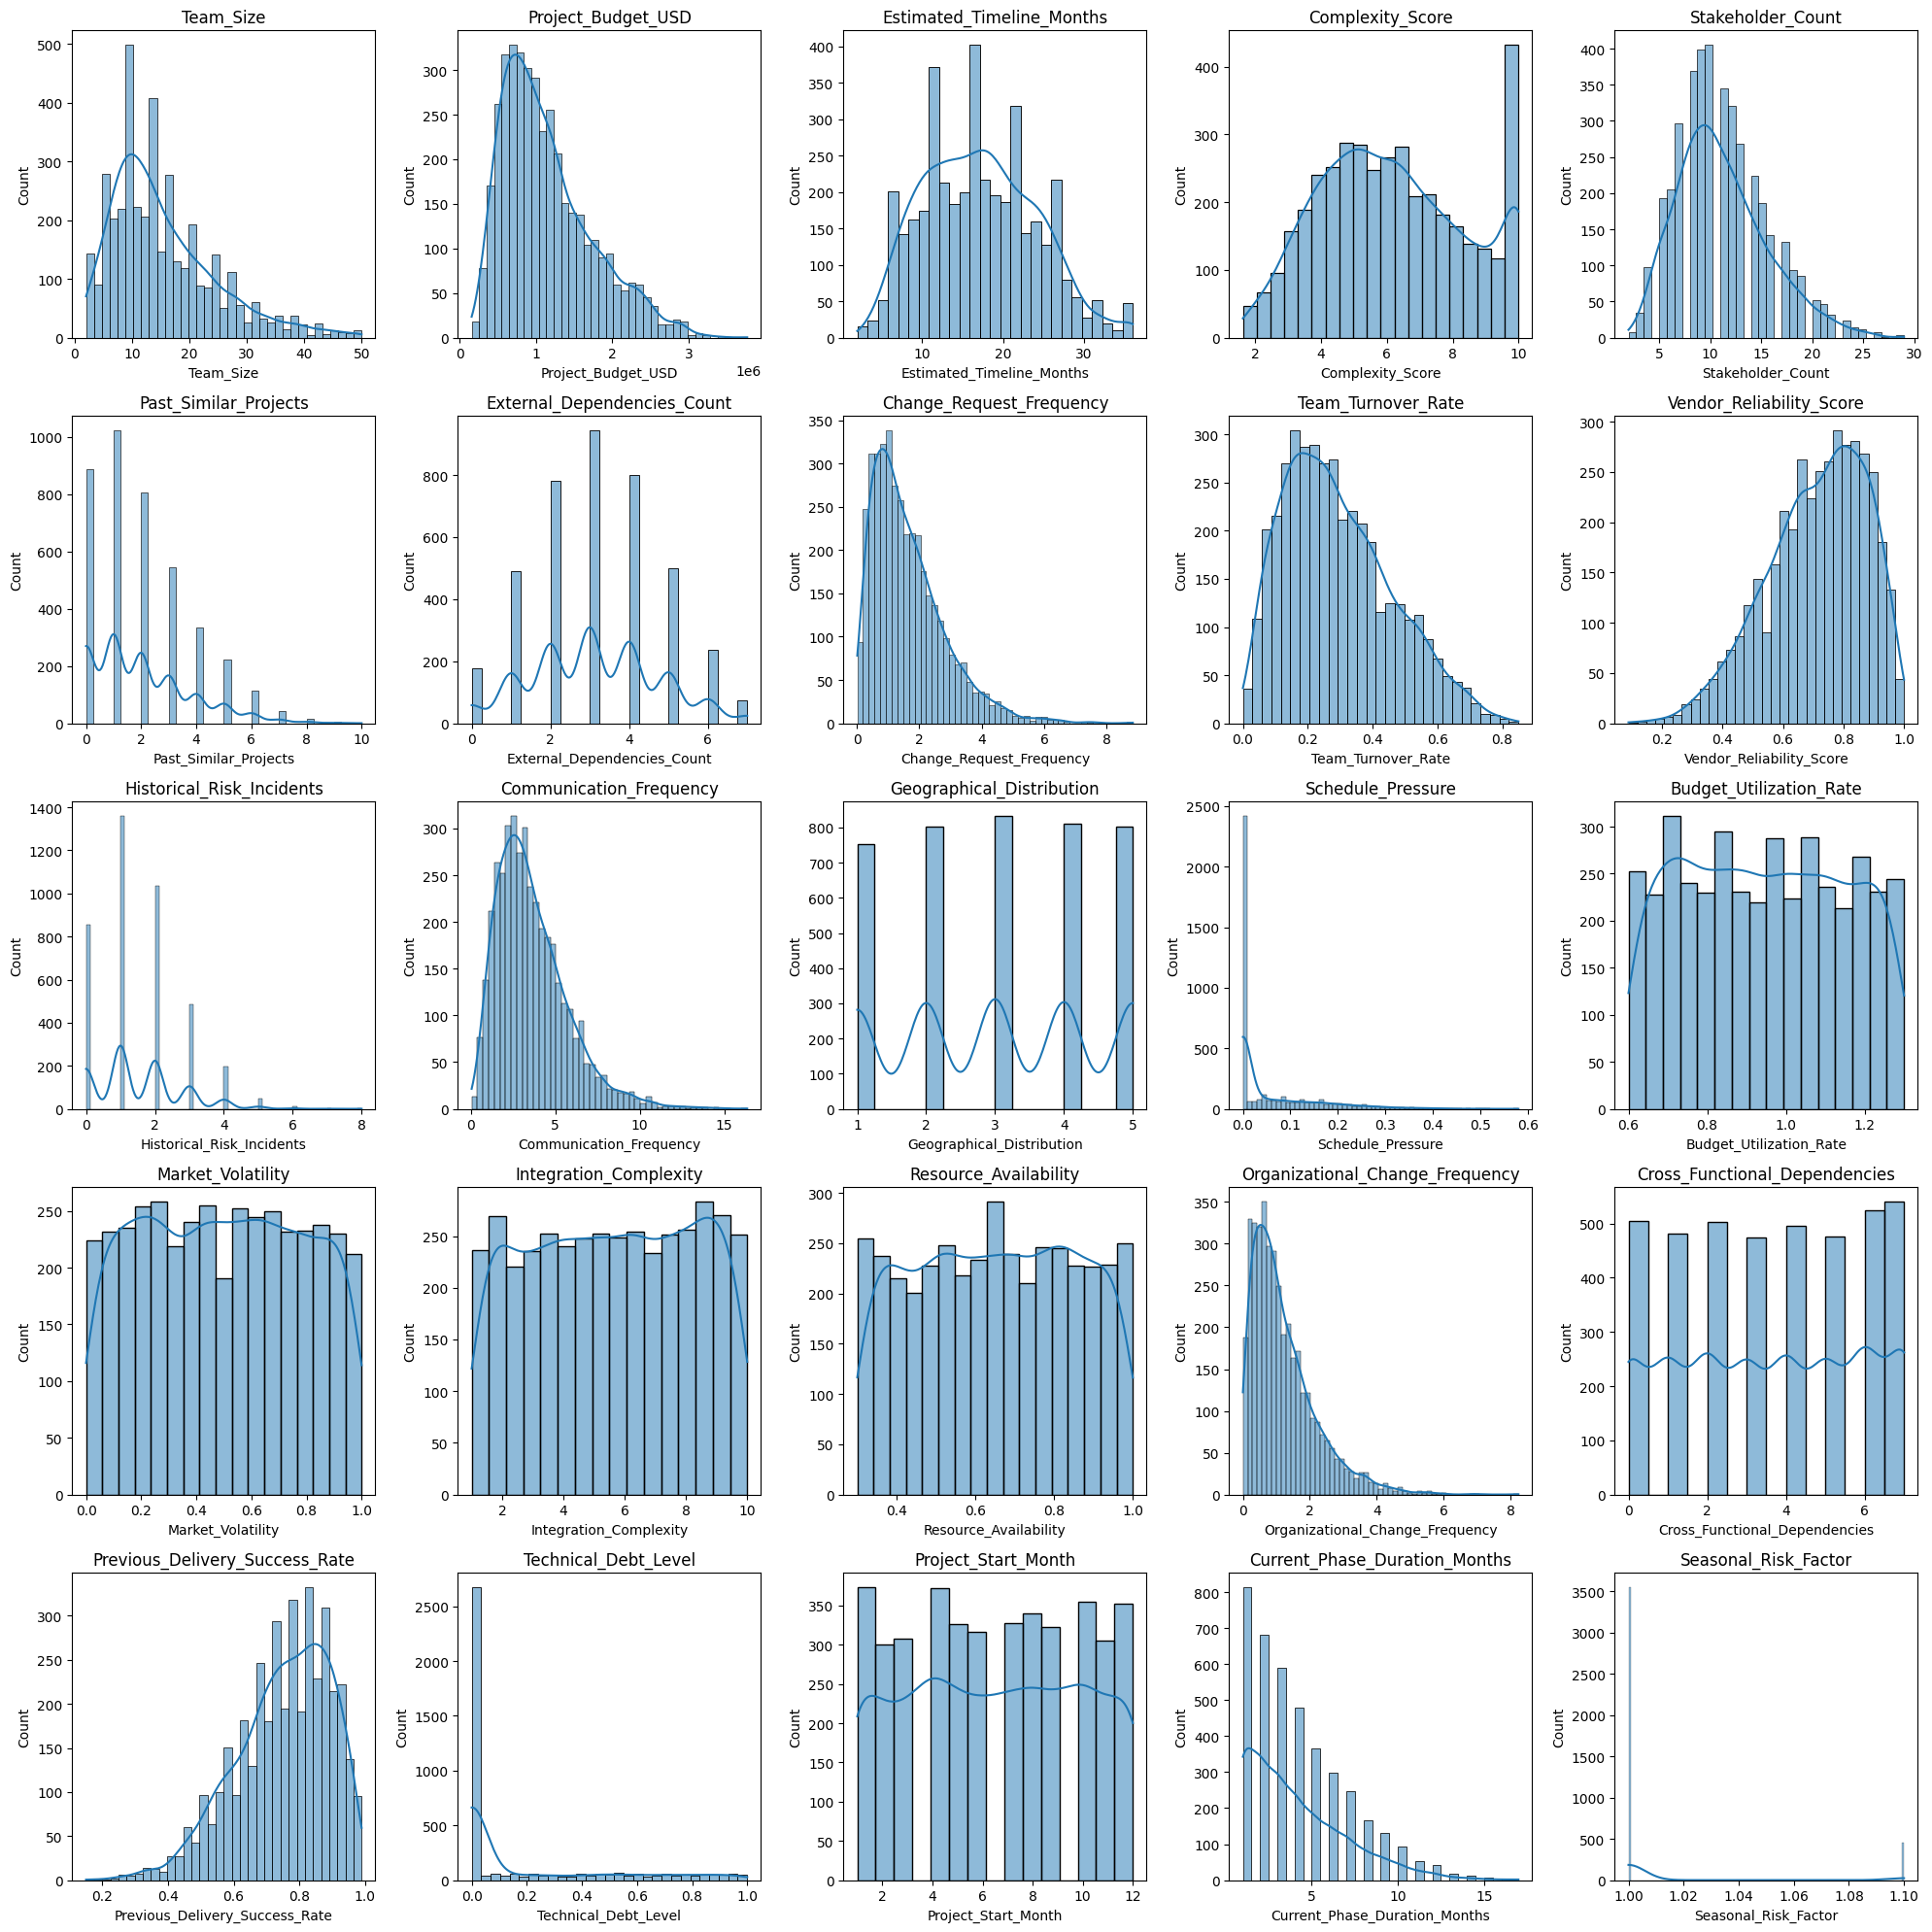

In [11]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
n_cols = 5
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [12]:
data = data.drop(columns=['Tech_Environment_Stability', 'Project_ID'], errors='ignore')

After cleaning: (2701, 49)


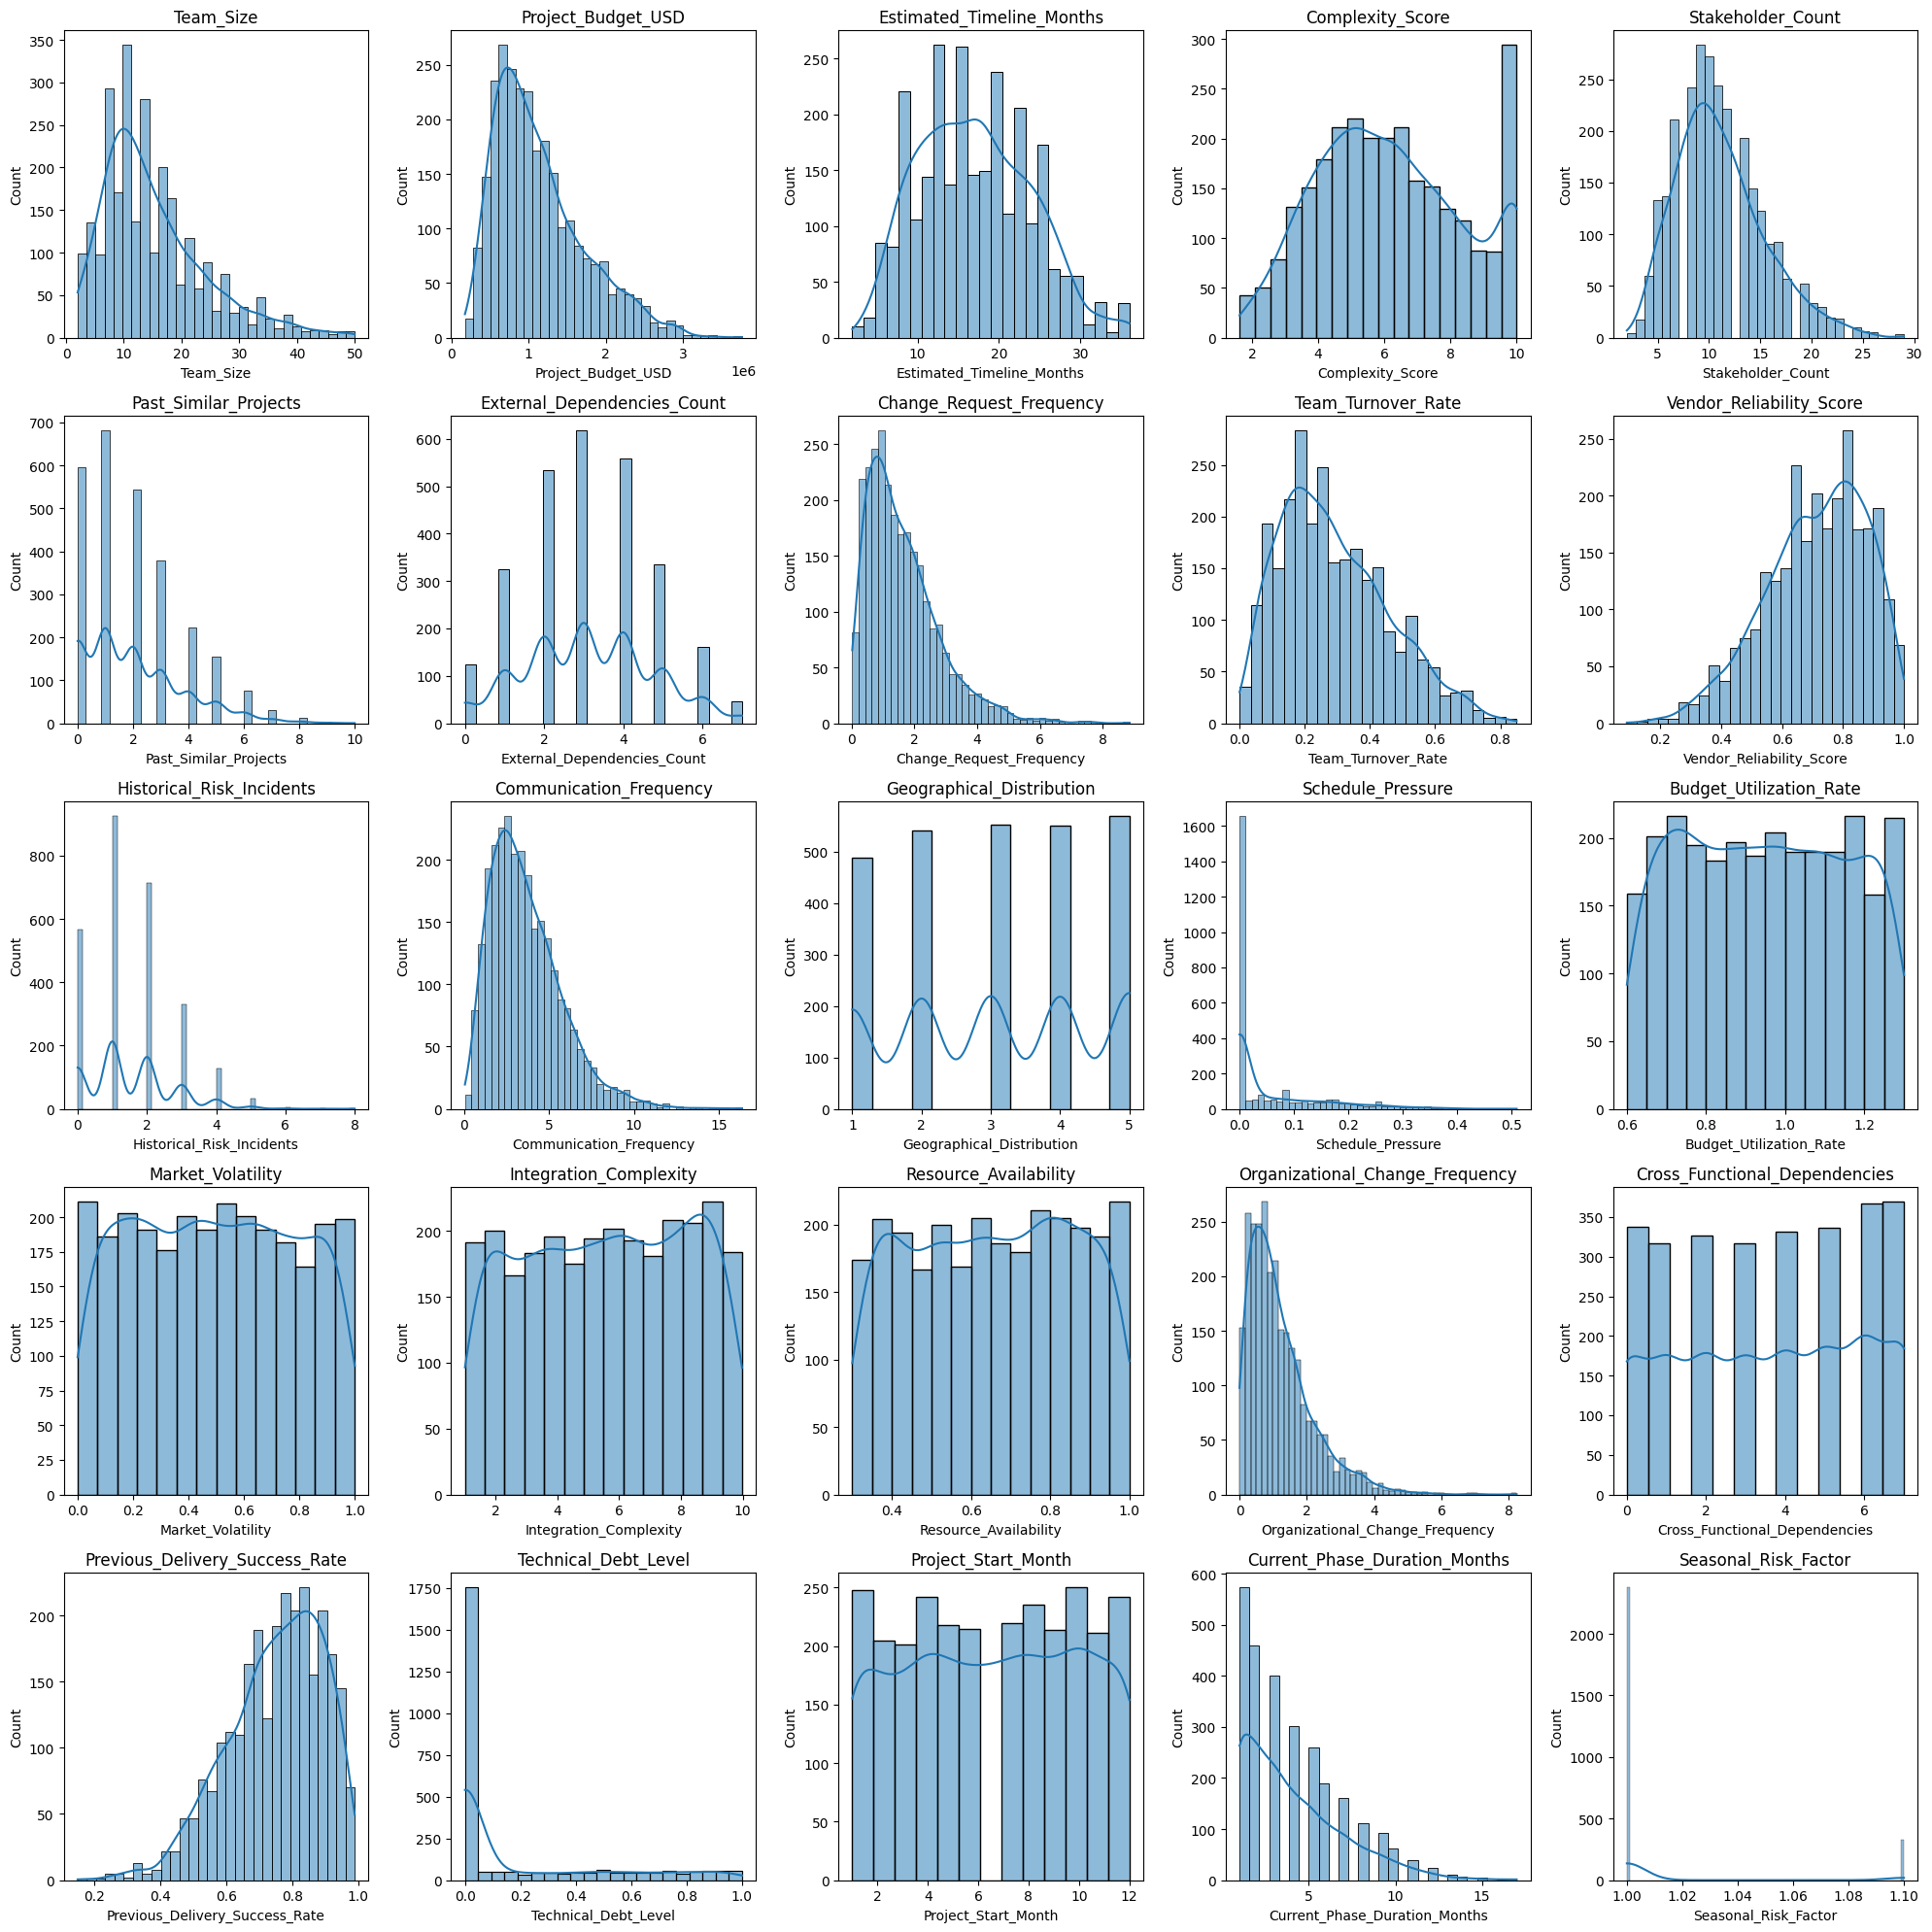

In [13]:
data = data.dropna(subset=['Change_Control_Maturity', 'Risk_Management_Maturity'])
print("After cleaning:", data.shape)

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
n_cols = 5
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [14]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('Risk_Level') if 'Risk_Level' in cat_cols else None

print(f"Numeric features: {len(num_cols)}, Categorical features: {len(cat_cols)}")

Numeric features: 25, Categorical features: 23


In [15]:
X = data.drop("Risk_Level", axis=1)
y = data["Risk_Level"]

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

le = LabelEncoder()
y = le.fit_transform(y)
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))


Classes: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


In [17]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7134935304990758
Confusion Matrix:
 [[ 48  21   0   2]
 [ 24  75   0  29]
 [  0   0 115  25]
 [  4  25  25 148]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.68      0.65        71
           1       0.62      0.59      0.60       128
           2       0.82      0.82      0.82       140
           3       0.73      0.73      0.73       202

    accuracy                           0.71       541
   macro avg       0.70      0.70      0.70       541
weighted avg       0.71      0.71      0.71       541



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=400, max_depth=15, random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.5526802218114603


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier())
])
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.5730129390018485


In [25]:
import os
import joblib

# save models in root/artifacts/models
os.makedirs("../artifacts/models", exist_ok=True)

joblib.dump(lr_model, "../artifacts/models/lr_model.pkl")
joblib.dump(rf_model, "../artifacts/models/rf_model.pkl")
joblib.dump(gb_model, "../artifacts/models/gb_model.pkl")

# save test data in root/data/test
os.makedirs("../data/test", exist_ok=True)

X_test.to_csv("../data/test/X_test.csv", index=False)
pd.DataFrame(y_test, columns=["Risk_Level"]).to_csv("../data/test/y_test.csv", index=False)

print("Everything saved successfully ✅")

Everything saved successfully ✅
